In [508]:
import taichi as ti
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import inspect

sp.init_printing("mathjax")

# Solving for angular acceleration

In [509]:
rcm, m, I, g, t = sp.symbols("r_{cm} m I g t")

theta = sp.Function("\\theta")(t)
theta_d = sp.diff(theta, t)

In [510]:
T = sp.Rational(1, 2) * I * theta_d**2
V = -m*g*rcm*sp.cos(theta)
L = T - V

In [511]:
eq_motion = sp.Equality(
    sp.diff(L, theta),
    sp.diff(
        sp.diff(L, theta_d),
        t
    )
)

acc = sp.solve(eq_motion, sp.diff(theta_d, t))[0]
acc_func = sp.lambdify((I, rcm, m, g, theta, theta_d), acc)

inspect.getsource(acc_func)

'def _lambdifygenerated(I, Dummy_369, m, g, _Dummy_368, _Dummy_367):\n    return -Dummy_369*g*m*sin(_Dummy_368)/I\n'

# RK4 Simulation

In [512]:
rcm_sim = 1
g_sim = 9.81
I_sim = 1/3 * (2*rcm_sim)**2
m_sim = 1

y = np.array([np.pi - 0.001, 0.1])

def f(y, t):
    return np.array([
        y[1],
        acc_func(I_sim, rcm_sim, m_sim, g_sim, y[0], y[1])
    ])

h = 0.001
t = 0
sim_time = 10

In [513]:
past_positions = np.array([])
first = True

for i in range(int(sim_time/h)):
    k1 = h*f(y, t)
    k2 = h*f(y + k1/2, t + h/2)
    k3 = h*f(y + k2/2, t + h/2)
    k4 = h*f(y + k3, t + h)

    y = y + k1/6 + k2/3 + k3/3 + k4/6

    if (first):
        past_positions = np.array([y])
        first = False
    else:
        past_positions = np.vstack([past_positions, y])


Getting the position of the end of the arm. Note: I'm now assuming the arm is a solid bar.

In [514]:
# getting the simulated angles out
theta_sim = past_positions[:, 0]

data_rate = 30 #the rate at which (simulated) data is recorded
indices_to_keep = np.linspace(0, len(theta_sim)-1, sim_time*data_rate, dtype=int)
theta_sim_data = theta_sim[indices_to_keep]

# simulating the position measurements we would get, including uncertainties

x_sim_err = np.random.normal(0, 0.1, len(theta_sim_data))
y_sim_err = np.random.normal(0, 0.1, len(theta_sim_data))

x_sim = 2*rcm_sim*np.sin(theta_sim_data) + x_sim_err
y_sim = -2*rcm_sim*np.cos(theta_sim_data) + y_sim_err

In [515]:
# fig, ax = plt.subplots()
# ax.set_aspect('equal')
# ax.set_xlim(-2.2*2*rcm_sim, 2.2*2*rcm_sim)
# ax.set_ylim(-2.2*2*rcm_sim, 2.2*2*rcm_sim)

# line, = ax.plot([], [], "o-", lw=1)

# def init():
#     line.set_data([], [])
#     return line,

# def update(i):
#     this_x = [0, x_sim[i]]
#     this_y = [0, y_sim[i]]

#     line.set_data(this_x, this_y)
#     return line,

# ani = FuncAnimation(fig, update, frames=len(theta_sim), init_func=init, blit=True, interval=10)

# ani.save("test_single.mp4")

In [ ]:
data = np.vstack(
    (
        np.arange(0, sim_time, 1/data_rate),
        x_sim,
        y_sim,
        x_sim_err,
        y_sim_err
    )
).transpose()

data

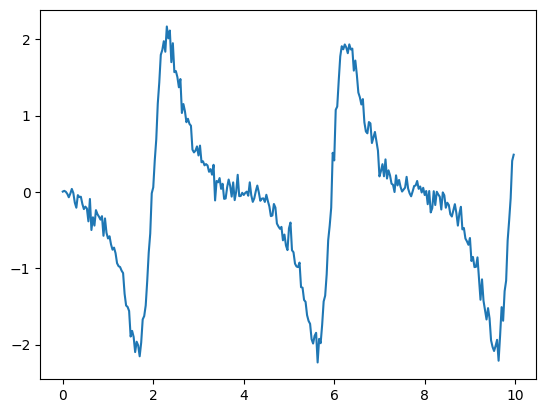

In [517]:
plt.plot(data[:, 0], data[:, 1])